## Assignment Computer Vision 03-05


1. Provide a watermark `top-secret.png` on the receipt image contained in this attachment `ReceiptSwiss.jpg`

2. Modify the code in the notebook below so that when you click for the first time it will display a point on the video, and when you click for the second time it will display a circle with a radius that is the distance from the first click point to the distance from the second click point.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [3]:
img1 = cv2.imread("ReceiptSwiss.jpg")

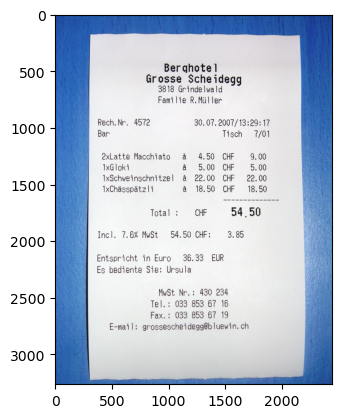

In [4]:
plt.imshow(img1)

In [8]:
img2 = cv2.imread("top-secret.png")

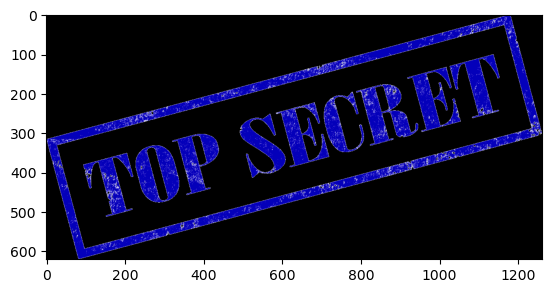

In [9]:
plt.imshow(img2)

### Convert to Different Colorspaces

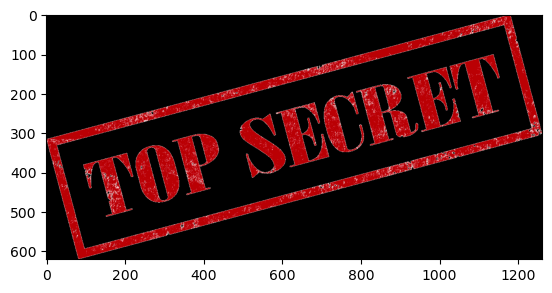

In [10]:
# BGR to RGB
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
plt.imshow(img2)

In [17]:
img1 = cv2.imread('ReceiptSwiss.jpg')
img2 = cv2.imread('top-secret.png')

In [18]:
img1.shape

(3264, 2448, 3)

In [19]:
img2.shape

(621, 1262, 3)

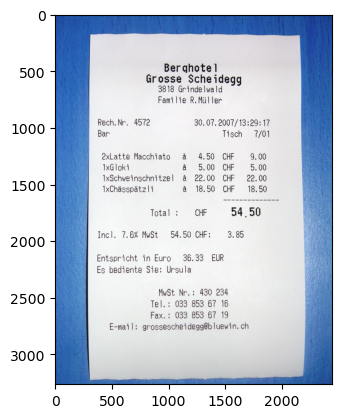

In [21]:
plt.imshow(img1)

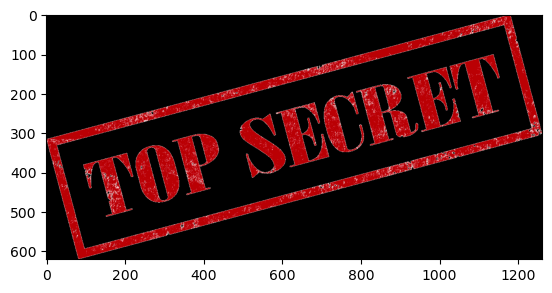

In [23]:
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
plt.imshow(img2)

### Resize the Image

In [25]:
img1 = cv2.resize(img1, (1200,1200))
img2 = cv2.resize(img2, (1200,1200))

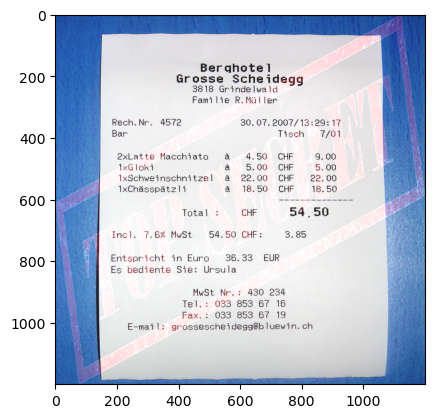

In [27]:
# coba blend tanpa resize gambar

blended = cv2.addWeighted(src1=img1, alpha=1, src2=img2, beta=0.3, gamma=0)
plt.imshow(blended)

### Overlaying Images of Different Sizes

In [38]:
#Load ulang gambar

img1 = cv2.imread('ReceiptSwiss.jpg')
img2 = cv2.imread('top-secret.png')

img2 = cv2.resize(img2, (800,800))

In [39]:
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

In [40]:
large_img = img1
small_img = img2

In [41]:
x_offset = 1000
y_offset = 1000

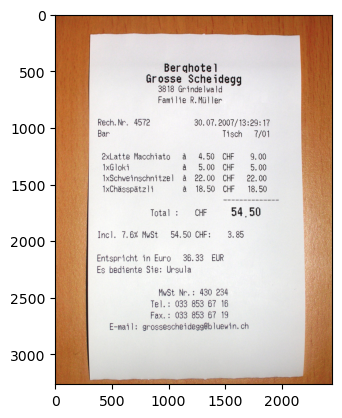

In [42]:
plt.imshow(large_img)

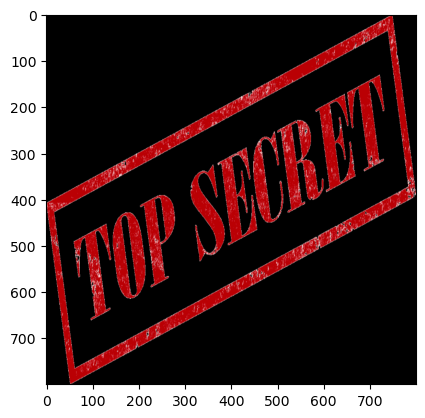

In [43]:
plt.imshow(small_img)

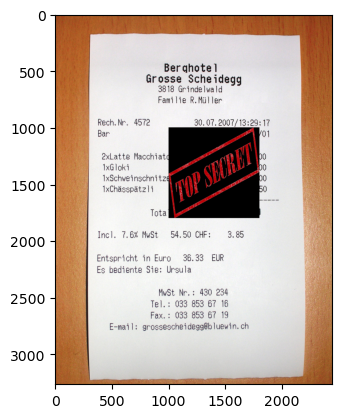

In [44]:
#Insert image

large_img[y_offset:small_img.shape[0]+y_offset, x_offset:small_img.shape[1]+x_offset] = small_img
plt.imshow(large_img)

### Blending Images of Different Sizes

In [49]:
#Load ulang gambar

img1 = cv2.imread('ReceiptSwiss.jpg')
img2 = cv2.imread('top-secret.png')

img2 = cv2.resize(img2, (800,800))

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

In [50]:
img1.shape

(3264, 2448, 3)

In [64]:
#karna akan kita taruh di kanan bawah
x_offset = 2448-2200
y_offset = 3264-2200

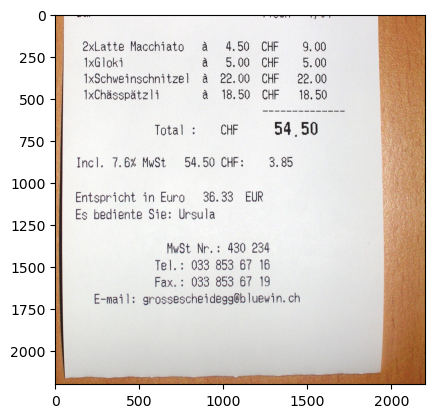

In [65]:
roi = img1[y_offset:3264, x_offset:2448]
plt.imshow(roi)

In [66]:
roi.shape

(2200, 2200, 3)

### Create a Mask

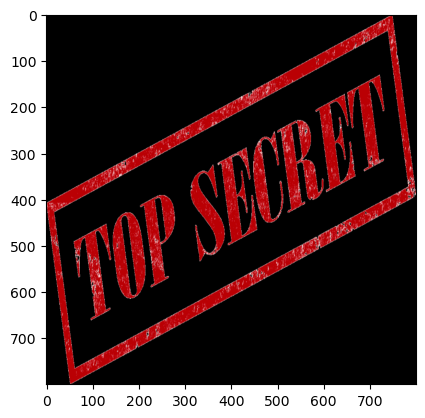

In [45]:
plt.imshow(img2)

In [77]:
img2_gray = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

In [78]:
img2_gray.shape

(800, 800)

In [79]:
img2_gray

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

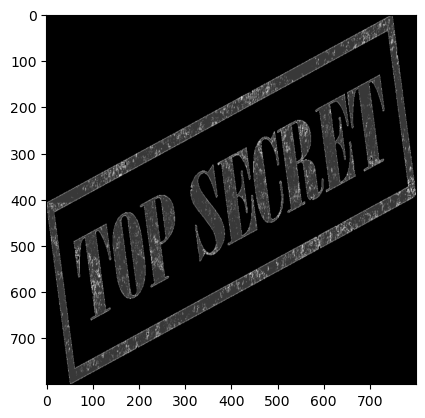

In [80]:
plt.imshow(img2_gray, cmap = 'gray')

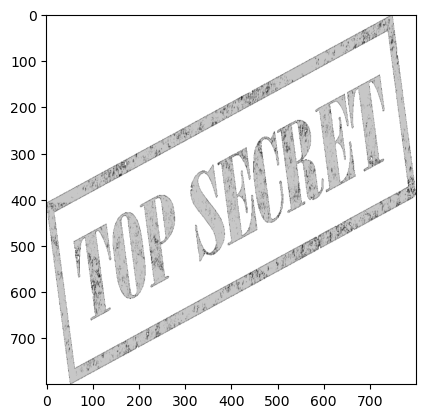

In [81]:
#invert nilai / warna nya

mask_inv = cv2.bitwise_not(img2_gray)
plt.imshow(mask_inv, cmap='gray')

In [82]:
white_background = np.full(img2.shape, 255, dtype=np.uint8)

In [83]:
white_background.shape

(800, 800, 3)

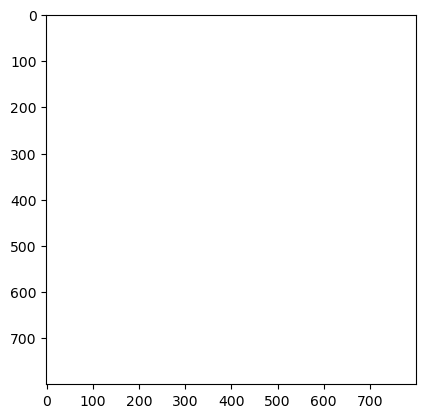

In [84]:
plt.imshow(white_background)

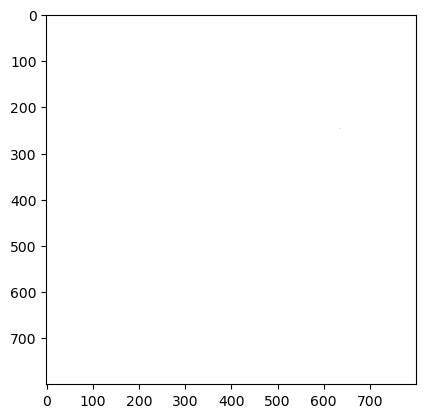

In [90]:
mask_3c = cv2.bitwise_or(white_background, white_background, mask=mask_inv)
plt.imshow(mask_3c)

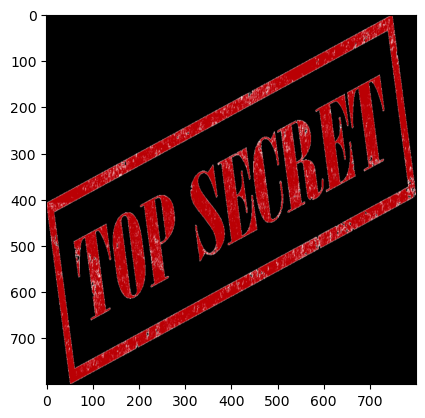

In [87]:
watermark = cv2.bitwise_or(img2, img2, mask=mask_inv)
plt.imshow(watermark)

In [92]:
watermark.shape

(800, 800, 3)

In [94]:
watermark

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)

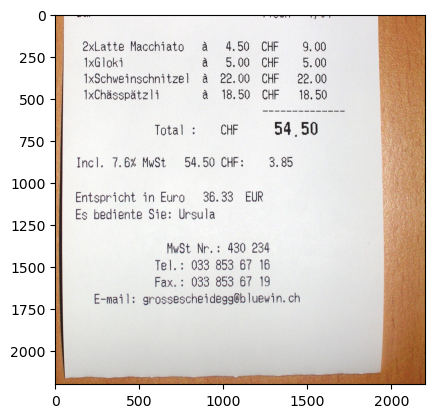

In [97]:
plt.imshow(roi)

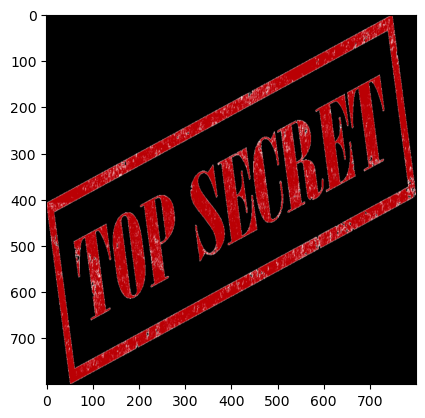

In [98]:
plt.imshow(watermark)

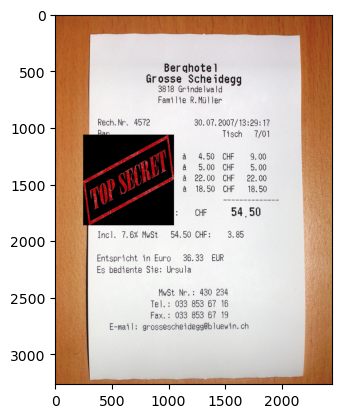

In [101]:
large_img = img1
small_img = watermark
large_img[y_offset:y_offset+small_img.shape[0] , x_offset:x_offset+small_img.shape[1]] = small_img

plt.imshow(large_img)

 Modify the code in the notebook below so that when you click for the first time it will display a point on the video, and when you click for the second time it will display a circle with a radius that is the distance from the first click point to the distance from the second click point.

In [ ]:
import cv2
import math

# Mouse callback function
def draw_circle(event, x, y, flags, param):
    global pt1, pt2, first_click, second_click

    if event == cv2.EVENT_LBUTTONDOWN:
        if not first_click:
            pt1 = (x, y)
            first_click = True
        elif not second_click:
            pt2 = (x, y)
            second_click = True

# Initialize variables
pt1 = (0, 0)
pt2 = (0, 0)
first_click = False
second_click = False

# Capture video from the webcam
cap = cv2.VideoCapture(0)

# Create a named window for connections
cv2.namedWindow('Test')

# Bind draw_circle function to mouse clicks
cv2.setMouseCallback('Test', draw_circle)

while True:
    # Capture frame-by-frame
    ret, frame = cap.read()

    if first_click:
        cv2.circle(frame, center=pt1, radius=5, color=(0, 0, 255), thickness=-1)

    if first_click and second_click:
        # Calculate the distance between the two points
        radius = int(math.sqrt((pt2[0] - pt1[0]) ** 2 + (pt2[1] - pt1[1]) ** 2))
        cv2.circle(frame, center=pt1, radius=radius, color=(0, 0, 255), thickness=2)

    # Display the resulting frame
    cv2.imshow('Test', frame)

    # This command lets us quit with the "q" button on a keyboard.
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# When everything is done, release the capture
cap.release()
cv2.destroyAllWindows()